In [1]:
import torch
print(torch.cuda.is_available())

True


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!wget https://s3-us-west-1.amazonaws.com/udacity-dlnfd/datasets/celeba.zip

--2026-04-05 09:53:04--  https://s3-us-west-1.amazonaws.com/udacity-dlnfd/datasets/celeba.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 52.219.120.136, 16.15.0.205, 52.219.192.32, ...
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|52.219.120.136|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1443490838 (1.3G) [application/zip]
Saving to: ‘celeba.zip’

celeba.zip          100%[===================>]   1.34G  23.8MB/s    in 68s     

2026-04-05 09:54:14 (20.1 MB/s) - ‘celeba.zip’ saved [1443490838/1443490838]



In [6]:
!unzip celeba.zip

Streaming output truncated to the last 5000 lines.
 extracting: img_align_celeba/197600.jpg  
 extracting: img_align_celeba/197601.jpg  
 extracting: img_align_celeba/197602.jpg  
 extracting: img_align_celeba/197603.jpg  
 extracting: img_align_celeba/197604.jpg  
 extracting: img_align_celeba/197605.jpg  
 extracting: img_align_celeba/197606.jpg  
 extracting: img_align_celeba/197607.jpg  
 extracting: img_align_celeba/197608.jpg  
 extracting: img_align_celeba/197609.jpg  
 extracting: img_align_celeba/197610.jpg  
 extracting: img_align_celeba/197611.jpg  
 extracting: img_align_celeba/197612.jpg  
 extracting: img_align_celeba/197613.jpg  
 extracting: img_align_celeba/197614.jpg  
 extracting: img_align_celeba/197615.jpg  
 extracting: img_align_celeba/197616.jpg  
 extracting: img_align_celeba/197617.jpg  
 extracting: img_align_celeba/197618.jpg  
 extracting: img_align_celeba/197619.jpg  
 extracting: img_align_celeba/197620.jpg  
 extracting: img_align_celeba/197621.jpg  
 ex

In [7]:
!ls

 celeba.zip   drive   img_align_celeba	'main copy.ipynb'   sample_data


In [8]:
import os
import shutil

os.makedirs("datasets/celeb", exist_ok=True)

files = os.listdir("img_align_celeba")

for f in files:
    shutil.move(f"img_align_celeba/{f}", f"datasets/celeb/{f}")

In [9]:
!ls datasets/celeb | head

000001.jpg
000002.jpg
000003.jpg
000004.jpg
000005.jpg
000006.jpg
000007.jpg
000008.jpg
000009.jpg
000010.jpg


In [10]:
root="datasets"

In [11]:
# MODEL FOR SEMENTIC INPAINTING

import torch
import torch.nn as nn


class _netG(nn.Module):
    def __init__(self, opt):
        super(_netG, self).__init__()
        self.ngpu = opt.ngpu
        self.main = nn.Sequential(
            # input is (nc) x 128 x 128
            nn.Conv2d(opt.nc,opt.nef,4,2,1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef) x 64 x 64
            nn.Conv2d(opt.nef,opt.nef,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef) x 32 x 32
            nn.Conv2d(opt.nef,opt.nef*2,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef*2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef*2) x 16 x 16
            nn.Conv2d(opt.nef*2,opt.nef*4,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef*4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef*4) x 8 x 8
            nn.Conv2d(opt.nef*4,opt.nef*8,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef*8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef*8) x 4 x 4
            nn.Conv2d(opt.nef*8,opt.nBottleneck,4, bias=False),
            # tate size: (nBottleneck) x 1 x 1
            nn.BatchNorm2d(opt.nBottleneck),
            nn.LeakyReLU(0.2, inplace=True),
            # input is Bottleneck, going into a convolution
            nn.ConvTranspose2d(opt.nBottleneck, opt.ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(opt.ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(opt.ngf * 8, opt.ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(opt.ngf * 4, opt.ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(opt.ngf * 2, opt.ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d(opt.ngf, opt.nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 64 x 64
        )

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output


class _netlocalD(nn.Module):
    def __init__(self, opt):
        super(_netlocalD, self).__init__()
        self.ngpu = opt.ngpu
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(opt.nc, opt.ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(opt.ndf, opt.ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(opt.ndf * 2, opt.ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(opt.ndf * 4, opt.ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(opt.ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # final : 1 X 1 X 1
        )

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)

        return output.view(-1)
        # .view(-1,1) : [batch_size X 1 X 1 x 1] --> [batch_size]

In [12]:
# Creating directories :

import os

try :
    os.makedirs("result/train/cropped")
    os.makedirs("result/train/real")
    os.makedirs("result/test/recon")
    os.makedirs("models")
except OSError :
    pass

In [13]:
# Random Seed Initialization :
import random
seed = random.randint(1,10000)
print(f"Random seed is : {seed}")

print(f"GPU availability : {torch.cuda.is_available()}")

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


Random seed is : 2601
GPU availability : True


In [14]:
target_dir = "datasets/train"

In [15]:
# Downloading the dataset

'''
I am using CelebA dataset, you can choose any dataset as you wish
'''
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Path to dataset files:", path)



Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [16]:
import os
import shutil
from glob import glob

images_path = os.path.join(path, 'img_align_celeba/img_align_celeba')
target_dir = "datasets/train"
os.makedirs(target_dir, exist_ok=True)
celeb_images = os.path.join(target_dir, "celeba")
os.makedirs(celeb_images, exist_ok=True)


if os.path.exists(images_path):
    image_files = glob(os.path.join(images_path, '*'))

    print(f"Found {len(image_files)} files to copy")

    for i, source_file in enumerate(image_files):
        if i % 1000 == 0:
            print(f"Copied {i}/{len(image_files)} files...")

        filename = os.path.basename(source_file)
        destination = os.path.join(celeb_images, filename)
        shutil.copy2(source_file, destination)

    print(f"Successfully copied all images to {celeb_images}")

Found 202599 files to copy
Copied 0/202599 files...
Copied 1000/202599 files...
Copied 2000/202599 files...
Copied 3000/202599 files...
Copied 4000/202599 files...
Copied 5000/202599 files...
Copied 6000/202599 files...
Copied 7000/202599 files...
Copied 8000/202599 files...
Copied 9000/202599 files...
Copied 10000/202599 files...
Copied 11000/202599 files...
Copied 12000/202599 files...
Copied 13000/202599 files...
Copied 14000/202599 files...
Copied 15000/202599 files...
Copied 16000/202599 files...
Copied 17000/202599 files...
Copied 18000/202599 files...
Copied 19000/202599 files...
Copied 20000/202599 files...
Copied 21000/202599 files...
Copied 22000/202599 files...
Copied 23000/202599 files...
Copied 24000/202599 files...
Copied 25000/202599 files...
Copied 26000/202599 files...
Copied 27000/202599 files...
Copied 28000/202599 files...
Copied 29000/202599 files...
Copied 30000/202599 files...
Copied 31000/202599 files...
Copied 32000/202599 files...
Copied 33000/202599 files...


In [17]:
# Creating Dataset and DataLoader :
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
img_transfrom = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.CenterCrop(size=(128,128)),
    transforms.ToTensor(), # (0,255) -> (0,1.0) int -> float
    transforms.Normalize(mean=(0.5,0.5,0.5),std=(0.5, 0.5,0.5)) # (0,1) --> (-1,1) # commanly used in gans
])

In [18]:
# Creating Dataset and DataLoader :
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
dataset = datasets.ImageFolder(root=target_dir, transform=img_transfrom)
data_loader =  DataLoader(dataset, num_workers=2, shuffle=True, batch_size=64)

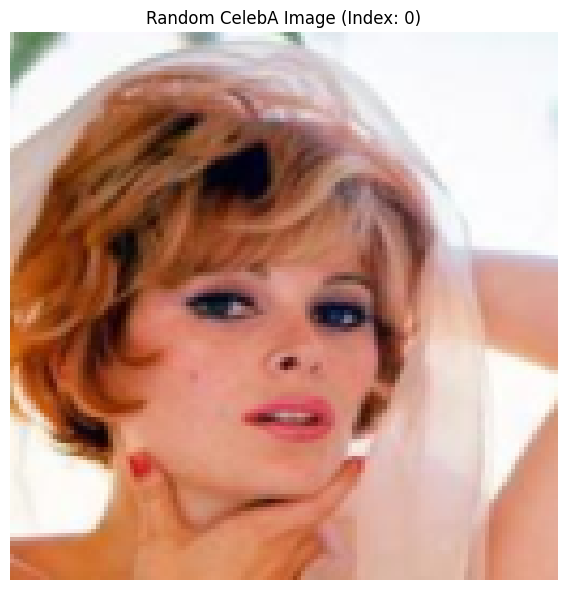

In [19]:
import matplotlib.pyplot as plt
import random
import torch

def get_random_image():
    batch_data, batch_label = next(iter(data_loader))
    random_number = random.randint(0, len(batch_data)-1)
    random_image = batch_data[random_number]

    # Convert from tensor format for display
    # From: (C, H, W) with range [-1, 1]
    # To: (H, W, C) with range [0, 1]

    # Denormalize: reverse the normalization (x - 0.5) / 0.5 -> x * 0.5 + 0.5
    denormalized_image = random_image * 0.5 + 0.5 # (-1,1) -> (0,1)

    # Convert from (C, H, W) to (H, W, C) for matplotlib
    display_image = denormalized_image.permute(1, 2, 0)

    # Clamp values to [0, 1] range (in case of small floating point errors)
    display_image = torch.clamp(display_image, 0, 1)

    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(display_image)
    plt.axis('off')  # Remove axes
    plt.title(f'Random CelebA Image (Index: {random_number})')
    plt.tight_layout()
    plt.show()

    return random_image, random_number

# Call the function
random_image, index = get_random_image()

In [20]:
import argparse

opt = {
    "ngpu" : int(1),
    "ngf" : int(64),
    "ndf" : int(64),
    "nc" : int(3),
    "lr" : float(0.0002),
    "beta1" : float(0.5),
    "nBottleneck" : int(4000),
    "nef" : int(64),
    "wtl2" : float(0.998),
    "wtlD" : float(0.001),
    "overlapL2Weight" : 10,
    "batchSize" : int(64),
    "imageSize" : int(128),
    "overlap" : int(4)
}

opt = argparse.Namespace(**opt)


In [21]:
# initializing models with custom weights

def weight_init(m) :
    classname = m.__class__.__name__
    with torch.no_grad() :
        if classname.find('Conv') != -1 :
            m.weight.normal_(0.0, 0.02) #(mean, std)
        elif classname.find('BatchNorm') != -1 :
            m.weight.normal_(1.0, 0.02) # (mean, std)
            m.bias.data.fill_(0)

netG = _netG(opt)
netG.apply(weight_init)

netD = _netlocalD(opt)
netD.apply(weight_init)

_netlocalD(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [22]:
criterion = nn.BCELoss()
criterionMSE = nn.MSELoss()
input_real = torch.FloatTensor(opt.batchSize, 3, opt.imageSize, opt.imageSize)
input_cropped = torch.FloatTensor(opt.batchSize, 3, opt.imageSize, opt.imageSize)
label = torch.FloatTensor(opt.batchSize)
real_label = 1.0
fake_label = 0.0
real_center = torch.FloatTensor(opt.batchSize, 3, (opt.imageSize)//2, (opt.imageSize)//2)

In [23]:
# Setting up the device :
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device found : ", device)
if device == "cuda" :
    criterion.to(device)
    criterionMSE.to(device)
    netD.to(device)
    netG.to(device)
    input_real, input_cropped, label = input_real.to(device), input_cropped.to(device), label.to(device)
    real_center = real_center.to(device)

print("All components moved to device successfully")

Device found :  cuda
All components moved to device successfully


In [24]:
# setup optimizer
import torch.optim as optim
optimizerD = optim.Adam(netD.parameters(), lr=opt.lr, betas=(opt.beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=opt.lr, betas=(opt.beta1, 0.999))

print("Optimizers set up successfully")

Optimizers set up successfully


In [26]:
import os
os.makedirs("result/train/recon", exist_ok=True)
print("Folder created!")

Folder created!


In [27]:
# Training loop :
import torchvision.utils as vutils
epochs = 5
G_losses = []
D_losses = []
G_D_losses = []  # Adversarial loss component
G_L2_losses = []  # L2 loss component


for epoch in range(epochs) :
    epoch_G_loss = 0
    epoch_D_loss = 0
    epoch_G_D_loss = 0
    epoch_G_L2_loss = 0
    num_batches = 0
    for i, data in enumerate(data_loader, 0) :
        real_cpu, _ = data # Uncropped real data
        real_center_cpu = real_cpu[:, :, opt.imageSize//4 : opt.imageSize//4 + opt.imageSize//2, opt.imageSize//4 : opt.imageSize//4 + opt.imageSize//2]
        # real_center_cpu is centre real data
        batch_size = real_cpu.shape[0]

        # Copying into our tensors
        input_real.data.resize_(real_cpu.size()).copy_(real_cpu) # real unmasked image
        input_cropped.data.resize_(real_cpu.size()).copy_(real_cpu) # real masked image
        real_center.data.resize_(real_center_cpu.size()).copy_(real_center_cpu) # real centre part

        # Masking :
        input_cropped.data[:, 0, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*117.0/255 - 1.0
        input_cropped.data[:, 1, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*104.0/255 - 1.0
        input_cropped.data[:, 2, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*123.0/255 - 1.0

        # we filled the center part with gray color of the 3 channels
        # we are actually predicting some less pixels (4 px less from each side)

        # Updating Discriminator :
        # train with real image
        netD.zero_grad()
        label.data.resize_(batch_size).fill_(real_label)

        output = netD(real_center)
        errD_real = criterion(output, label) # BCE Loss
        errD_real.backward()
        D_x = output.data.mean()

        # train with fake image :
        fake = netG(input_cropped) # the generator only generates masked region
        # i.e fake is [batch, channels, 64, 64]
        label.data.fill_(fake_label)
        output = netD(fake.detach()) # we use fake.detach() because if not used :
        '''
        Gradients would flow back through:
        err D_fake → netD → fake → netG,
        This would accidentally update the Generator during Discriminator training!
        '''
        errD_fake = criterion(output, label) #BCE loss
        errD_fake.backward()
        D_G_z1 = output.data.mean()

        errD = errD_fake + errD_real
        optimizerD.step()

        # Updating Context Encoder / Generator :
        netG.zero_grad()
        label.data.fill_(real_label) # fake labels are real for generator cost
        output = netD(fake)
        errG_D = criterion(output, label) # this is adversial loss

        # wtl2
        wtl2Matrix = real_center.clone() # [batch, 3, 64,64]
        wtl2Matrix.data.fill_(opt.wtl2*10)
        wtl2Matrix.data[:, :, opt.overlap : opt.imageSize // 2 - opt.overlap,  opt.overlap : opt.imageSize // 2 - opt.overlap] = opt.wtl2

        # weight matrix :
        # kept weights higher for the border to make the blending smooth
        '''
        [99.8  99.8  99.8  99.8  99.8  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  99.8  99.8  99.8  99.8  99.8]

        '''

        errG_l2 = (fake - real_center).pow(2)
        errG_l2 = errG_l2 * wtl2Matrix
        errG_l2 = errG_l2.mean() # this is l2 weighted error

        errG = (1 - opt.wtl2) * errG_D + opt.wtl2 * errG_l2 # this is joint error
        errG.backward()

        D_G_z2 = output.data.mean()
        optimizerG.step()

        epoch_G_loss += errG.item()
        epoch_D_loss += errD.item()
        epoch_G_D_loss += errG_D.item()
        epoch_G_L2_loss += errG_l2.item()
        num_batches += 1

        print('[%d/%d][%d/%d] Loss_D: %.4f Loss_G: %.4f / %.4f l_D(x): %.4f l_D(G(z)): %.4f'
                  % (epoch, epochs, i, len(data_loader),
                     errD.item(), errG_D.item(),errG_l2.item(), D_x,D_G_z1, ))
        if i % 100 == 0:
            with torch.no_grad():  # Disable gradients for inference
                # Save original images
                vutils.save_image(real_cpu,
                    f'result/train/real/real_samples_epoch_{epoch:03d}_iter_{i:04d}.png',
                    normalize=True, nrow=8)

                # Save input (with holes)
                vutils.save_image(input_cropped,
                    f'result/train/cropped/cropped_samples_epoch_{epoch:03d}_iter_{i:04d}.png',
                    normalize=True, nrow=8)

                # Create and save reconstruction
                recon_image = input_cropped.clone()
                recon_image[:, :, 32:96, 32:96] = fake  # Use integer division
                vutils.save_image(recon_image,
                    f'result/train/recon/recon_samples_epoch_{epoch:03d}_iter_{i:04d}.png',
                    normalize=True, nrow=8)

    G_losses.append(epoch_G_loss / num_batches)
    D_losses.append(epoch_D_loss / num_batches)
    G_D_losses.append(epoch_G_D_loss / num_batches)
    G_L2_losses.append(epoch_G_L2_loss / num_batches)
    torch.save({'epoch':epoch+1,
                'state_dict':netG.state_dict()},
                'models/netG_streetview.pth' )
    torch.save({'epoch':epoch+1,
                'state_dict':netD.state_dict()},
                'models/netlocalD.pth' )

Streaming output truncated to the last 5000 lines.
[3/5][1332/3166] Loss_D: 0.4331 Loss_G: 3.2039 / 0.0622 l_D(x): 0.8478 l_D(G(z)): 0.2056
[3/5][1333/3166] Loss_D: 0.5196 Loss_G: 2.3976 / 0.0644 l_D(x): 0.7379 l_D(G(z)): 0.1396
[3/5][1334/3166] Loss_D: 1.4491 Loss_G: 0.3120 / 0.0623 l_D(x): 0.3078 l_D(G(z)): 0.0499
[3/5][1335/3166] Loss_D: 0.9464 Loss_G: 3.2136 / 0.0615 l_D(x): 0.9927 l_D(G(z)): 0.5358
[3/5][1336/3166] Loss_D: 0.2354 Loss_G: 4.4359 / 0.0623 l_D(x): 0.9914 l_D(G(z)): 0.1903
[3/5][1337/3166] Loss_D: 0.4934 Loss_G: 2.8390 / 0.0665 l_D(x): 0.7047 l_D(G(z)): 0.0730
[3/5][1338/3166] Loss_D: 0.2424 Loss_G: 2.6663 / 0.0626 l_D(x): 0.8871 l_D(G(z)): 0.1014
[3/5][1339/3166] Loss_D: 0.3265 Loss_G: 3.3346 / 0.0681 l_D(x): 0.9521 l_D(G(z)): 0.2242
[3/5][1340/3166] Loss_D: 0.2293 Loss_G: 3.8802 / 0.0634 l_D(x): 0.9442 l_D(G(z)): 0.1445
[3/5][1341/3166] Loss_D: 0.6853 Loss_G: 2.2373 / 0.0594 l_D(x): 0.6878 l_D(G(z)): 0.1983
[3/5][1342/3166] Loss_D: 1.1770 Loss_G: 0.5085 / 0.0585 l_D

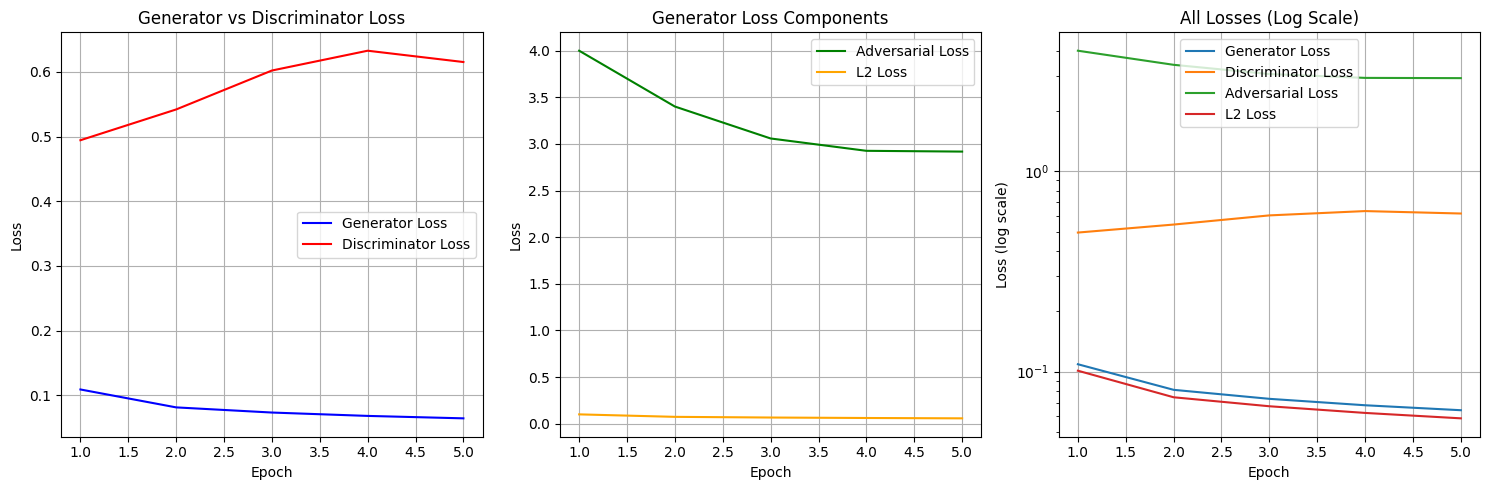

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_losses(G_losses, D_losses, G_D_losses, G_L2_losses):
    plt.figure(figsize=(15, 5))

    # Plot 1: Generator and Discriminator losses
    plt.subplot(1, 3, 1)
    plt.plot(range(1, len(G_losses) + 1), G_losses, label='Generator Loss', color='blue')
    plt.plot(range(1, len(D_losses) + 1), D_losses, label='Discriminator Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generator vs Discriminator Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Generator loss components
    plt.subplot(1, 3, 2)
    plt.plot(range(1, len(G_D_losses) + 1), G_D_losses, label='Adversarial Loss', color='green')
    plt.plot(range(1, len(G_L2_losses) + 1), G_L2_losses, label='L2 Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generator Loss Components')
    plt.legend()
    plt.grid(True)

    # Plot 3: All losses together (log scale might be helpful)
    plt.subplot(1, 3, 3)
    plt.semilogy(range(1, len(G_losses) + 1), G_losses, label='Generator Loss')
    plt.semilogy(range(1, len(D_losses) + 1), D_losses, label='Discriminator Loss')
    plt.semilogy(range(1, len(G_D_losses) + 1), G_D_losses, label='Adversarial Loss')
    plt.semilogy(range(1, len(G_L2_losses) + 1), G_L2_losses, label='L2 Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('All Losses (Log Scale)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_losses.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the plotting function after training
plot_losses(G_losses, D_losses, G_D_losses, G_L2_losses)

In [30]:
# importing the models :
netG_path = "models/netG_streetview.pth"
netD_path = "models/netlocalD.pth"

netG = _netG(opt)
netD = _netlocalD(opt)
checkpoint_G = torch.load(netG_path, weights_only=True)
checkpoint_D = torch.load(netD_path, weights_only=True)

# Load only the state_dict part
netG.load_state_dict(checkpoint_G['state_dict'])
netD.load_state_dict(checkpoint_D['state_dict'])

netG = netG.to(device)
netD = netD.to(device)

print("Models loaded successfully!")

Models loaded successfully!


In [32]:
from PIL import Image
image_path = "/content/_VIS4107.JPG"   # ← paste your actual path here
pil_image = Image.open(image_path)
image_tensor = img_transfrom(pil_image)
image_tensor.unsqueeze(0).shape

torch.Size([1, 3, 128, 128])

In [36]:
def fill(path):
    netG.eval()
    with torch.no_grad():
        pil_image = Image.open(path)          # ← use path, not image_path
        image_tensor = img_transfrom(pil_image)
        batch = image_tensor.unsqueeze(0)
        batch = batch.to(device)              # ← ADD THIS LINE

        batch.data[:, 0, opt.imageSize//4 + opt.overlap : opt.imageSize//4 + opt.imageSize//2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize//4 + opt.imageSize//2 - opt.overlap] = 2*117.0/255 - 1.0
        batch.data[:, 1, opt.imageSize//4 + opt.overlap : opt.imageSize//4 + opt.imageSize//2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize//4 + opt.imageSize//2 - opt.overlap] = 2*104.0/255 - 1.0
        batch.data[:, 2, opt.imageSize//4 + opt.overlap : opt.imageSize//4 + opt.imageSize//2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize//4 + opt.imageSize//2 - opt.overlap] = 2*123.0/255 - 1.0

        fake = netG(batch)

        vutils.save_image(batch, 'result/train/cropped/cropped_train.png', normalize=True, nrow=1)

        recon_image = batch.clone()
        recon_image[:, :, 32:96, 32:96] = fake
        vutils.save_image(recon_image, 'result/train/recon/recon_test.png', normalize=True, nrow=1)
        print("Successfully saved the image!")

In [37]:
image_path = "/content/_VIS4107.JPG"   # ← same path as Cell 18
fill(image_path)

Successfully saved the image!


Successfully saved the image!


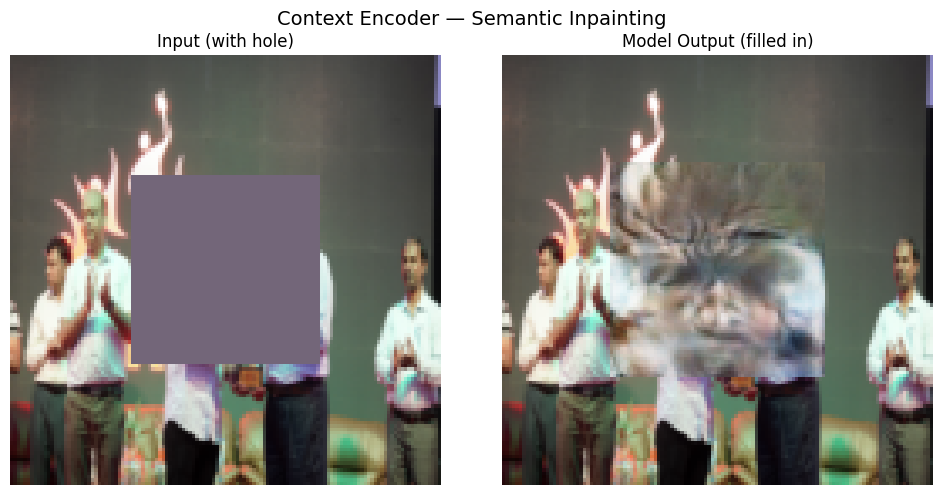

In [38]:
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def inpaint_and_show(image_path):
    # Run the model
    fill(image_path)

    # Load and show both images side by side
    cropped = plt.imread('result/train/cropped/cropped_train.png')
    recon = plt.imread('result/train/recon/recon_test.png')

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cropped)
    axes[0].set_title('Input (with hole)')
    axes[0].axis('off')
    axes[1].imshow(recon)
    axes[1].set_title('Model Output (filled in)')
    axes[1].axis('off')
    plt.suptitle('Context Encoder — Semantic Inpainting', fontsize=14)
    plt.tight_layout()
    plt.show()

# Use it like this:
inpaint_and_show("/content/_VIS4107.JPG")